Моревой Дарьи, 23ФПЛ2

# **Вариант 2. Анализ тональности отзывов о товарах**


*Тема:* «Автоматическое определение тональности (сентимент‑анализ) русскоязычных отзывов о товарах с применением глубоких нейросетевых моделей».

*Цель:* создать систему для автоматического определения тональности отзывов (позитивный, негативный, нейтральный) с высокой точностью.


*Задачи:*
1. Собрать корпус отзывов о товарах из интернет‑магазинов (не менее 20 000 отзывов) или использовать открытые датасеты.
2. Разметить данные по тональности (ручная или полуавтоматическая разметка).
3. Провести предобработку текста: нормализацию, токенизацию, удаление шума.
4. Обучить модели сентимент‑анализа:
классические ML‑модели (Logistic Regression, Naive Bayes);
глубокие модели (LSTM, Transformer на базе ruBERT).
5. Сравнить эффективность моделей по метрикам: accuracy, F1‑score, confusion matrix.
6. Исследовать влияние контекста и сленга на точность анализа.
7. Реализовать API для интеграции системы в сторонние сервисы.


*Ожидаемый результат:* модель с accuracy не менее 0,9, код проекта с документацией, отчёт с сравнением методов и рекомендациями по улучшению.


Отзывы на мобильные телефоны (старые и новые) в необработанном виде с рейтингом от 1 до 5. Датасет представлен в сыром виде: есть пропущенные и аномальные значения, а также дубликаты. Около 320 тысяч уникальных значений.

Ссылка на Kaggle: https://www.kaggle.com/datasets/theovall/phonereviews

Для ускорения выполнения проекта было выбрано только 20 тысяч строк из общей таблицы с данными.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data.csv")
df.head(10)

,Review,Rating
0,3D Touch просто восхитительная вещь! Заряд дер...,5
1,"Отключается при температуре близкой к нулю, не...",4
2,"В Apple окончательно решили не заморачиваться,...",3
3,Постарался наиболее ёмко и коротко описать все...,4
4,Достойный телефон. Пользоваться одно удовольст...,5
5,6s gold 64gb,5
6,Мой первый айфон. Скажу честно- Эппл ранее ник...,5
7,Мне очень понравилась эта модель! Во-первых кл...,5
8,Долгое время пользовалась iPhone 5s 16Gb. Он м...,5
9,"Раньше был Samsung Galaxy Alpha SM-G850F 32Gb,...",4


Было выбрано только 25 тысяч строк из-за большого количества памяти датасета. Любой среде выполнения не хватает памяти реализовать подсчет большого количества данных без ожидания днями.При настоящем проекте потребовалось 3 часа минимум для полной оценки и загрузки.

In [3]:
df = df[:25000]

In [4]:
!pip install transformers datasets pandas scikit-learn

In [5]:
from transformers import pipeline

In [6]:
import torch
from tqdm import tqdm

In [7]:
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="blanchefort/rubert-base-cased-sentiment",
    tokenizer="blanchefort/rubert-base-cased-sentiment",
    device=device
)

def get_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return result['label'], result['score']
    except:
        return 'ERROR', 0.0

reviews_list = df['Review'].tolist()
total_reviews = len(reviews_list)

batch_size = 32
all_labels = []
all_scores = []

for i in tqdm(range(0, total_reviews, batch_size), desc="Батчи"):
    batch = reviews_list[i:i+batch_size]
    batch = [str(x)[:512] for x in batch]
    batch_results = sentiment_pipeline(batch)
    for r in batch_results:
        all_labels.append(r['label'])
        all_scores.append(r['score'])

df['sentiment'] = all_labels
df['confidence'] = all_scores

df_final = df[['Review', 'sentiment', 'confidence']]
df_final.to_csv('labeled_phone_reviews.csv', index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Батчи: 100%|██████████| 782/782 [05:02<00:00,  2.59it/s]


Сохранен файл с полуавтоматической разметкой тональности. Важно учесть, что была проведена предварительная проверка на ложные срабатывания: обнаружилось, что из 100 строк 8 можно отнести к другой тональности. Грубо говоря, модель может ошибаться в 8% случаев.

In [8]:
df_check = pd.read_csv('/content/labeled_phone_reviews.csv')
print(f"Загружено {len(df_check)} отзывов")

df_check.head(3)

Загружено 25000 отзывов


,Review,sentiment,confidence
0,3D Touch просто восхитительная вещь! Заряд дер...,POSITIVE,0.980784
1,"Отключается при температуре близкой к нулю, не...",NEGATIVE,0.751640
2,"В Apple окончательно решили не заморачиваться,...",NEUTRAL,0.806181


Также важно отметить, что есть столбец с уверенностью модели о размеченной тональности. В дальнейшей работе с моделями она не учитывается, но в перспективе можно рассмотреть.

# **Предобработка**

In [9]:
import re
tqdm.pandas(desc="Предобработка")

In [115]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [10]:
!pip install pymystem3

In [12]:
!pip install nltk

In [14]:
import pandas as pd
import re
from tqdm import tqdm
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('russian'))

In [15]:
from pymystem3 import Mystem
mystem = Mystem()

Installing mystem to /root/.local/bin/mystem from http://download.cdn.yandex.net/mystem/mystem-3.1-linux-64bit.tar.gz


Первым делом применяется функция нормализации, которая приводит каждый отзыв к нижнему регистру и удаляет все символы, кроме букв русского алфавита и пробелов, чтобы избавиться от посторонней пунктуации и латиницы; затем удаляются лишние пробелы. На следующем шаге происходит удаление шума: из текста вырезаются ссылки, адреса электронной почты и отдельно стоящие цифры, так как эти элементы не несут смысловой нагрузки для определения тональности. После очистки текст разбивается на отдельные слова с помощью простой токенизации, что даёт список токенов, который сохраняется в колонке tokens. Далее выполняется лемматизация, которая является ключевым этапом для русского языка из‑за его богатой морфологии; для этого используется библиотека pymystem3, которая приводит каждое слово к его нормальной словарной форме: существительные к именительному падежу единственного числа, глаголы к инфинитиву и так далее. Чтобы ускорить обработку большого объёма данных, лемматизация применяется пакетами по 1000 отзывов, что позволяет сократить время выполнения. Результат лемматизации сохраняется в колонке lemmas. Затем из полученных лемм удаляются стоп-слова, то есть наиболее частотные и смыслово нейтральные единицы, такие как предлоги, союзы, частицы и местоимения; для этого используется стандартный список стоп-слов из библиотеки NLTK, адаптированный для русского языка. Удаление стоп-слов необходимо для классических моделей машинного обучения, таких как логистическая регрессия и наивный байесовский классификатор, чтобы уменьшить размерность признакового пространства и убрать шум, не влияющий на тональность.

In [16]:
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^а-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_noise(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def simple_tokenize(text):
    return text.split()

def lemmatize_batch(tokens_batch):
    result = []
    for tokens in tokens_batch:
        lemmatized = []
        for token in tokens:
            try:
                lemma = mystem.lemmatize(token)[0]
                if lemma.strip():
                    lemmatized.append(lemma.strip())
            except:
                lemmatized.append(token)
        result.append(lemmatized)
    return result

def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [t for t in tokens if t.lower() not in STOPWORDS]
    return tokens

print("Нормализация текста")
df_check['clean_text'] = df_check['Review'].progress_apply(normalize_text)

print("Удаление шума")
df_check['clean_text'] = df_check['clean_text'].progress_apply(remove_noise)

print("Токенизация")
df_check['tokens'] = df_check['clean_text'].progress_apply(simple_tokenize)

print("Лемматизация")
batch_size = 1000
all_lemmatized = []

for i in tqdm(range(0, len(df_check), batch_size), desc="Лемматизация"):
    batch_tokens = df_check['tokens'].iloc[i:i+batch_size].tolist()
    batch_result = lemmatize_batch(batch_tokens)
    all_lemmatized.extend(batch_result)

df_check['lemmas'] = all_lemmatized

print("Удаление стоп-слов")
df_check['lemmas'] = df_check['lemmas'].progress_apply(remove_stopwords)

print("Примеры предобработки:")
print(df_check[['Review', 'clean_text', 'lemmas', 'sentiment']].head(10))

df_check.to_csv('preprocessed_phone_reviews_lemmatized.csv', index=False)
print("Сохранён preprocessed_phone_reviews_lemmatized.csv")

Нормализация текста


Предобработка: 100%|██████████| 25000/25000 [00:03<00:00, 8059.30it/s]


Удаление шума


Предобработка: 100%|██████████| 25000/25000 [00:04<00:00, 5708.34it/s]


Токенизация


...

Лемматизация


Лемматизация: 100%|██████████| 25/25 [04:21<00:00, 10.45s/it]


Удаление стоп-слов


Предобработка: 100%|██████████| 25000/25000 [00:00<00:00, 36500.39it/s]


Примеры предобработки:
                                              Review  \
0  3D Touch просто восхитительная вещь! Заряд дер...   
1  Отключается при температуре близкой к нулю, не...   
2  В Apple окончательно решили не заморачиваться,...   
3  Постарался наиболее ёмко и коротко описать все...   
4  Достойный телефон. Пользоваться одно удовольст...   
5                                       6s gold 64gb   
6  Мой первый айфон. Скажу честно- Эппл ранее ник...   
7  Мне очень понравилась эта модель! Во-первых кл...   
8  Долгое время пользовалась iPhone 5s 16Gb. Он м...   
9  Раньше был Samsung Galaxy Alpha SM-G850F 32Gb,...   

                                          clean_text  \
0  просто восхитительная вещь заряд держит целый ...   
1  отключается при температуре близкой к нулю неп...   
2  в окончательно решили не заморачиваться делая ...   
3  постарался наиболее ёмко и коротко описать все...   
4   достойный телефон пользоваться одно удовольствие   
5                       

# **Исследование датасета**

In [70]:
df = pd.read_csv('/content/preprocessed_phone_reviews_lemmatized.csv')
print(f"Загружено {len(df)} отзывов")
print(f"Распределение классов:\n{df['sentiment'].value_counts()}")

Загружено 25000 отзывов
Распределение классов:
sentiment
POSITIVE    12340
NEUTRAL      7027
NEGATIVE     5633
Name: count, dtype: int64


In [71]:
df.head()

,Review,sentiment,confidence,clean_text,tokens,lemmas
0,3D Touch просто восхитительная вещь! Заряд дер...,POSITIVE,0.980784,просто восхитительная вещь заряд держит целый ...,"['просто', 'восхитительная', 'вещь', 'заряд', ...","['просто', 'восхитительный', 'вещь', 'заряд', ..."
1,"Отключается при температуре близкой к нулю, не...",NEGATIVE,0.751640,отключается при температуре близкой к нулю неп...,"['отключается', 'при', 'температуре', 'близкой...","['отключаться', 'температура', 'близкий', 'нол..."
2,"В Apple окончательно решили не заморачиваться,...",NEUTRAL,0.806181,в окончательно решили не заморачиваться делая ...,"['в', 'окончательно', 'решили', 'не', 'заморач...","['окончательно', 'решать', 'заморачиваться', '..."
3,Постарался наиболее ёмко и коротко описать все...,NEUTRAL,0.691487,постарался наиболее ёмко и коротко описать все...,"['постарался', 'наиболее', 'ёмко', 'и', 'корот...","['постараться', 'наиболее', 'емко', 'короче', ..."
4,Достойный телефон. Пользоваться одно удовольст...,POSITIVE,0.804010,достойный телефон пользоваться одно удовольствие,"['достойный', 'телефон', 'пользоваться', 'одно...","['достойный', 'телефон', 'пользоваться', 'удов..."


In [72]:
df = df.dropna(subset=['clean_text'])

Для создания лейблов (кодирование) создали отдельный столбец.

In [73]:
label_map = {'POSITIVE': 0, 'NEGATIVE': 1, 'NEUTRAL': 2}
df['label'] = df['sentiment'].map(label_map)

In [74]:
df.head()

,Review,sentiment,confidence,clean_text,tokens,lemmas,label
0,3D Touch просто восхитительная вещь! Заряд дер...,POSITIVE,0.980784,просто восхитительная вещь заряд держит целый ...,"['просто', 'восхитительная', 'вещь', 'заряд', ...","['просто', 'восхитительный', 'вещь', 'заряд', ...",0
1,"Отключается при температуре близкой к нулю, не...",NEGATIVE,0.751640,отключается при температуре близкой к нулю неп...,"['отключается', 'при', 'температуре', 'близкой...","['отключаться', 'температура', 'близкий', 'нол...",1
2,"В Apple окончательно решили не заморачиваться,...",NEUTRAL,0.806181,в окончательно решили не заморачиваться делая ...,"['в', 'окончательно', 'решили', 'не', 'заморач...","['окончательно', 'решать', 'заморачиваться', '...",2
3,Постарался наиболее ёмко и коротко описать все...,NEUTRAL,0.691487,постарался наиболее ёмко и коротко описать все...,"['постарался', 'наиболее', 'ёмко', 'и', 'корот...","['постараться', 'наиболее', 'емко', 'короче', ...",2
4,Достойный телефон. Пользоваться одно удовольст...,POSITIVE,0.804010,достойный телефон пользоваться одно удовольствие,"['достойный', 'телефон', 'пользоваться', 'одно...","['достойный', 'телефон', 'пользоваться', 'удов...",0


Основная идея столбцов:

- `clean_text`служит очищенным текстом (строкой) без знаков препинания, с маленькой буквы, без шума. В основном именно данный формат использовался для глубоких моделей, т.к. они способны сами обработать текст, выявить синтаксическую и семантическую составляющую, чтобы уже определить тональность

- `tokens` служит списком уже с токенами, которые были выбраны из `clean_text`

- `lemmas` служит списком из лемм, которые были адаптированы с помощью библиотеки `pymystem3`для сравнения слов в предложениях с обучением обычных моделей

In [117]:
df = df.copy()

Количество записей: 24885
Количество колонок: 7
Колонки: ['Review', 'sentiment', 'confidence', 'clean_text', 'tokens', 'lemmas', 'label']
Типы данных:
Review         object
sentiment      object
confidence    float64
clean_text     object
tokens         object
lemmas         object
label           int64
dtype: object
Пропусков нет
Найдено дубликатов: 2448
Примеры дубликатов:
В Apple окончательно решили не заморачиваться, делая незначительные изменения в телефоне, выдают эти изменения за иннова...
Тональность: NEUTRAL

Постарался наиболее ёмко и коротко описать все основные плюсы и минусы. Большим мне аппарат не показался, размеры - что ...
Тональность: NEUTRAL

Достойный телефон. Пользоваться одно удовольствие.
Тональность: POSITIVE

Удалено записей: 2448
Итоговый размер: 22437
sentiment
POSITIVE    11148
NEUTRAL      6274
NEGATIVE     5015
Name: count, dtype: int64


/tmp/ipykernel_1404/2049003024.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis', order=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])


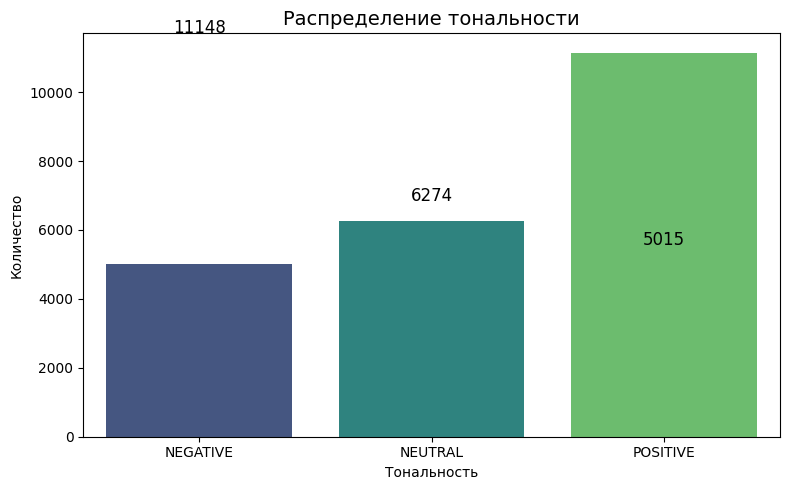

Статистика длины исходных отзывов:
count    22437.000000
mean       418.076570
std        448.102176
min          1.000000
25%        106.000000
50%        252.000000
75%        562.000000
max       2246.000000
Name: review_len, dtype: float64


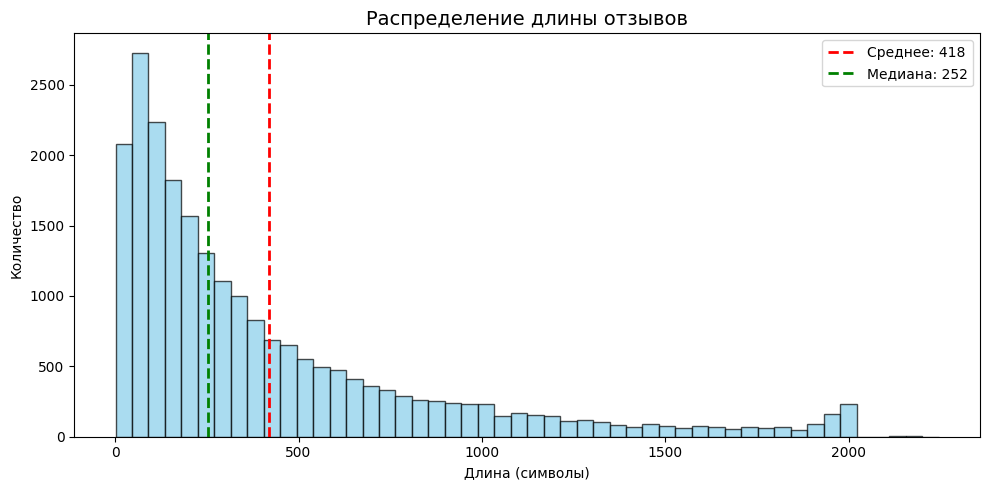

Статистика длины очищенных текстов:
count    22437.000000
mean       386.273967
std        413.757691
min          1.000000
25%         98.000000
50%        232.000000
75%        521.000000
max       2095.000000
Name: clean_len, dtype: float64


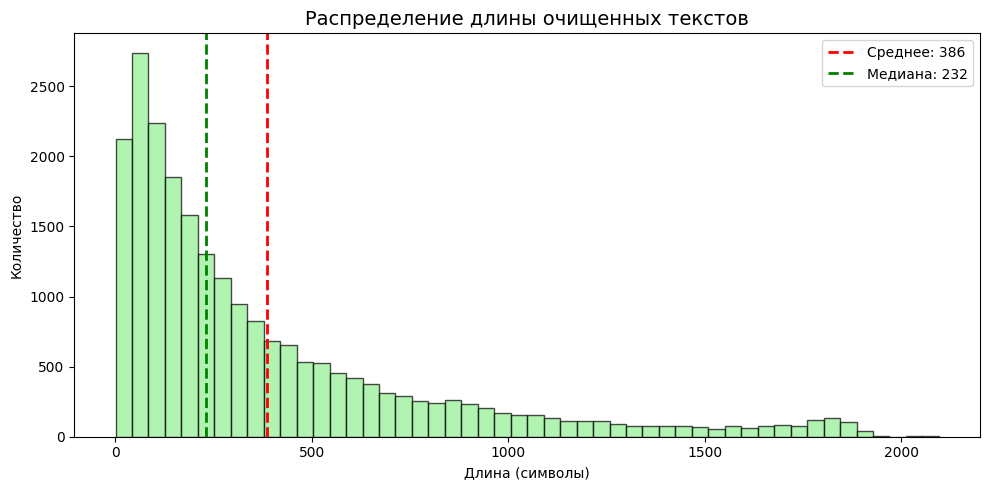

Уверенность модели
count    22437.000000
mean         0.832698
std          0.133945
min          0.335301
25%          0.751465
50%          0.818141
75%          0.970216
max          0.995464
Name: confidence, dtype: float64


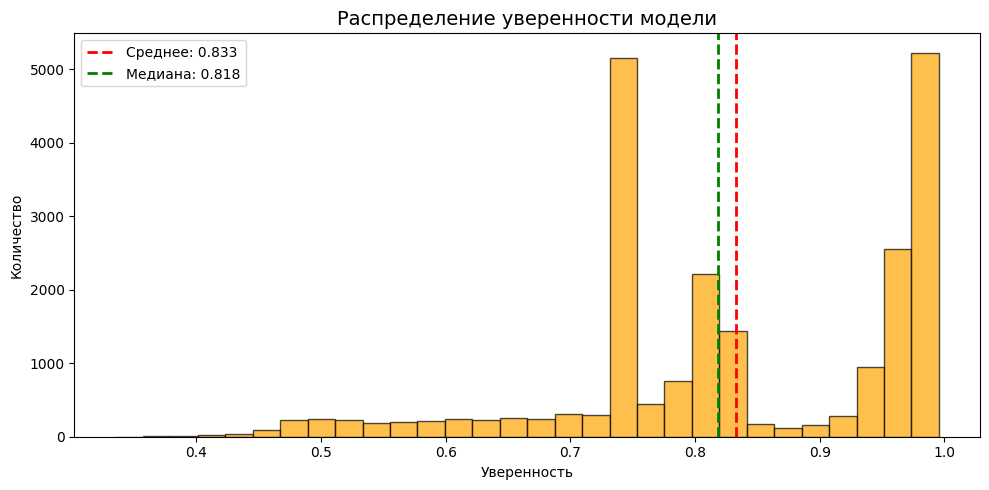

Топ-10 слов (из лемм без стоп-слов):
  'телефон',: 19758
  'это',: 14291
  'очень',: 9099
  'экран',: 6667
  'камера',: 5606
  'хороший',: 5460
  'день',: 4862
  'аппарат',: 4728
  'работать',: 4651
  'год',: 4524


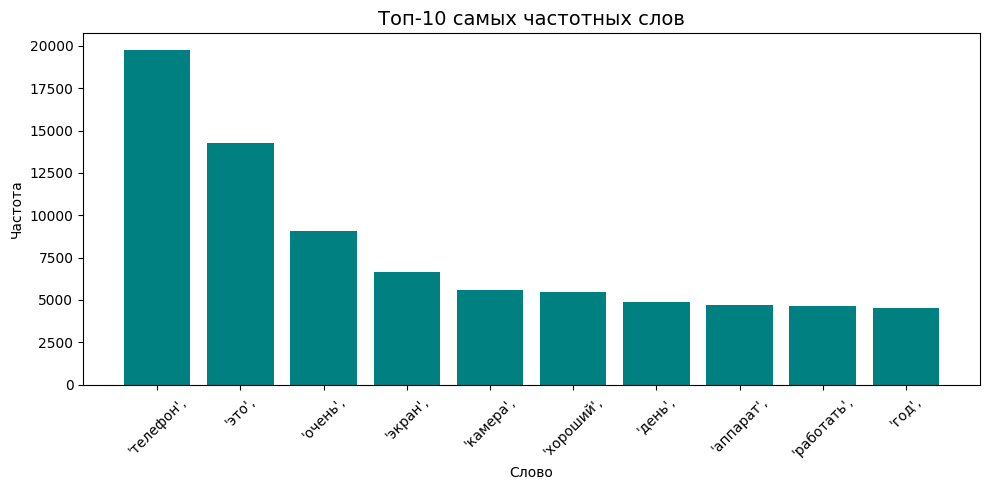

/tmp/ipykernel_1404/2049003024.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y=len_col, palette='Set2', order=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])


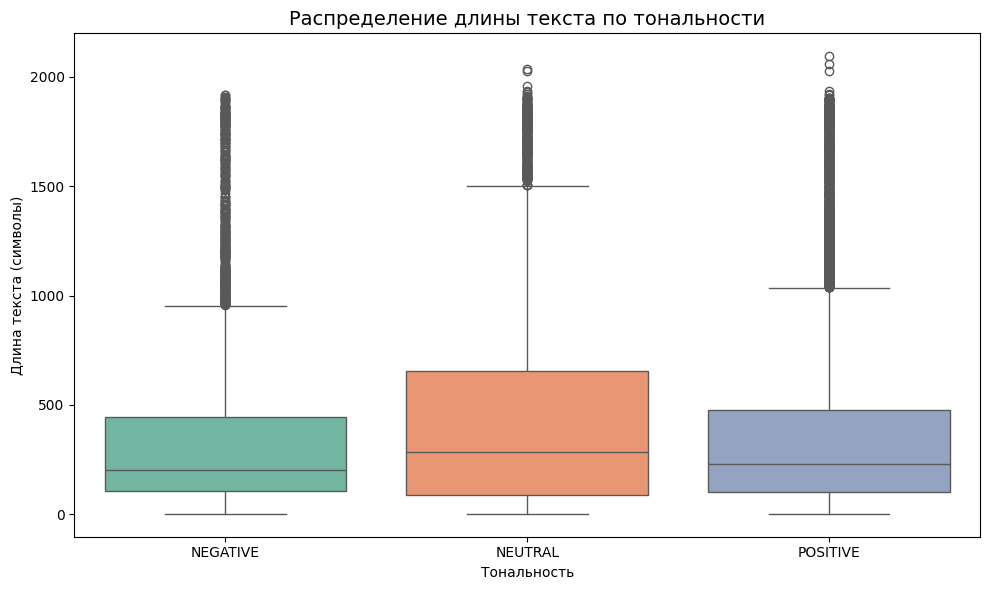

Средняя длина текста по тональности:
sentiment
NEGATIVE    347.0
NEUTRAL     455.0
POSITIVE    365.0
Name: clean_len, dtype: float64


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

print(f"Количество записей: {len(df)}")
print(f"Количество колонок: {len(df.columns)}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Типы данных:\n{df.dtypes}")

missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Пропусков нет")

text_col = 'Review' if 'Review' in df.columns else 'clean_text'

if text_col:
    dup_count = df.duplicated(subset=[text_col]).sum()
    print(f"Найдено дубликатов: {dup_count}")

    if dup_count > 0:
        dup_examples = df[df.duplicated(subset=[text_col], keep=False)].head(3)
        print("Примеры дубликатов:")
        for _, row in dup_examples.iterrows():
            preview = str(row[text_col])[:120] + "..." if len(str(row[text_col])) > 120 else row[text_col]
            print(f"{preview}")
            print(f"Тональность: {row.get('sentiment', 'нет')}")
            print()

        df = df.drop_duplicates(subset=[text_col], keep='first')
        print(f"Удалено записей: {dup_count}")
        print(f"Итоговый размер: {len(df)}")
    else:
        print("Дубликатов нет.")
else:
    print("Нет колонки с текстом для проверки дубликатов.")

if 'sentiment' in df.columns:
    sentiment_counts = df['sentiment'].value_counts()
    print(sentiment_counts)

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='sentiment', palette='viridis', order=['POSITIVE', 'NEUTRAL', 'NEGATIVE'])
    plt.title('Распределение тональности', fontsize=14)
    plt.xlabel('Тональность')
    plt.ylabel('Количество')
    for i, v in enumerate(sentiment_counts.values):
        plt.text(i, v + 0.05 * max(sentiment_counts.values), str(v), ha='center', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Колонка 'sentiment' не найдена.")

if 'Review' in df.columns:
    df['review_len'] = df['Review'].astype(str).str.len()
    print("Статистика длины исходных отзывов:")
    print(df['review_len'].describe())

    plt.figure(figsize=(10, 5))
    plt.hist(df['review_len'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(df['review_len'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {df["review_len"].mean():.0f}')
    plt.axvline(df['review_len'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {df["review_len"].median():.0f}')
    plt.title('Распределение длины отзывов', fontsize=14)
    plt.xlabel('Длина (символы)')
    plt.ylabel('Количество')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'clean_text' in df.columns:
    df['clean_len'] = df['clean_text'].astype(str).str.len()
    print("Статистика длины очищенных текстов:")
    print(df['clean_len'].describe())

    plt.figure(figsize=(10, 5))
    plt.hist(df['clean_len'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.axvline(df['clean_len'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {df["clean_len"].mean():.0f}')
    plt.axvline(df['clean_len'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {df["clean_len"].median():.0f}')
    plt.title('Распределение длины очищенных текстов', fontsize=14)
    plt.xlabel('Длина (символы)')
    plt.ylabel('Количество')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'confidence' in df.columns:
    print("Уверенность модели")
    print(df['confidence'].describe())

    plt.figure(figsize=(10, 5))
    plt.hist(df['confidence'], bins=30, color='orange', edgecolor='black', alpha=0.7)
    plt.axvline(df['confidence'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {df["confidence"].mean():.3f}')
    plt.axvline(df['confidence'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {df["confidence"].median():.3f}')
    plt.title('Распределение уверенности модели', fontsize=14)
    plt.xlabel('Уверенность')
    plt.ylabel('Количество')
    plt.legend()
    plt.tight_layout()
    plt.savefig('confidence_distribution.png', dpi=300)
    plt.show()

if 'lemmas' in df.columns:
    all_words = []
    for tokens in df['lemmas'].dropna():
        if isinstance(tokens, list):
            all_words.extend(tokens)
        elif isinstance(tokens, str):
            all_words.extend(tokens.split())

    if all_words:
        word_counter = Counter(all_words)
        top_words = word_counter.most_common(10)
        print("Топ-10 слов (из лемм без стоп-слов):")
        for word, count in top_words:
            print(f"  {word}: {count}")

        words, counts = zip(*top_words)
        plt.figure(figsize=(10, 5))
        plt.bar(words, counts, color='teal')
        plt.title('Топ-10 самых частотных слов', fontsize=14)
        plt.xlabel('Слово')
        plt.ylabel('Частота')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('top_words.png', dpi=300)
        plt.show()
    else:
        print("Нет данных для анализа.")
else:
    print("Колонка 'lemmas' не найдена.")

if 'sentiment' in df.columns and ('review_len' in df.columns or 'clean_len' in df.columns):
    len_col = 'clean_len' if 'clean_len' in df.columns else 'review_len'

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='sentiment', y=len_col, palette='Set2', order=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
    plt.title('Распределение длины текста по тональности', fontsize=14)
    plt.xlabel('Тональность')
    plt.ylabel('Длина текста (символы)')
    plt.tight_layout()
    plt.show()

    print("Средняя длина текста по тональности:")
    print(df.groupby('sentiment')[len_col].mean().round(0))

In [78]:
import ast
df['lemmas'] = df['lemmas'].apply(ast.literal_eval)

df['tokens'] = df['tokens'].apply(ast.literal_eval)

print(type(df['lemmas'].iloc[0]))
print(df['lemmas'].iloc[0][:5])

<class 'list'>
['просто', 'восхитительный', 'вещь', 'заряд', 'держать']


In [79]:
df = df[df['lemmas'].apply(lambda x: len(x) > 0)]
print(f"Размер после удаления пустых лемм: {len(df)}")

X = df['lemmas'].apply(lambda x: ' '.join(x)).values
y = df['label'].values

Размер после удаления пустых лемм: 22421


Параллельно с предобработкой проводился исследовательский анализ данных, который включал проверку на пропуски и дубликаты, визуализацию распределения тональности, анализ длины текстов, уверенности модели и самых частотных слов, что позволило лучше понять структуру данных и выявить дисбаланс классов — позитивных отзывов оказалось значительно больше, чем негативных и нейтральных, что потребовало использования метрик, устойчивых к дисбалансу, таких как F1-macro.

# **Сентимент-анализ LogisticRegression, Naive Bayes**

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 17936
Размер тестовой выборки: 4485


In [82]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Размер матрицы: {X_train_tfidf.shape}")

Размер матрицы: (17936, 15000)


In [83]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='liblinear'
)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f"Accuracy: {acc_lr:.4f}")
print(f"F1-macro: {f1_lr:.4f}")

Accuracy: 0.6511
F1-macro: 0.5906


In [84]:
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print(f"Accuracy: {acc_nb:.4f}")
print(f"F1-macro: {f1_nb:.4f}")

Accuracy: 0.5855
F1-macro: 0.4609


# **Сентимент-анализ LSTM, ruBERT**

In [85]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score

In [86]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df['clean_text'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label'].values
)

In [87]:
sample_size_lstm = 15000
indices = np.random.choice(len(X_train), sample_size_lstm)
X_train_lstm = X_train_text[indices]
y_train_lstm = y_train_text[indices]

In [88]:
print(f"Обучающая выборка LSTM: {len(X_train_lstm)} отзывов")

Обучающая выборка LSTM: 15000 отзывов


In [90]:
MAX_WORDS = 15000
MAX_LEN = 80

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train_lstm)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_lstm)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

print(f"Форма данных: {X_train_pad.shape}")

Форма данных: (15000, 80)


In [91]:
from tensorflow.keras.regularizers import l2

lstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_pad, y_train_lstm,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm, average='macro')

print(f"Accuracy: {acc_lstm:.4f}")
print(f"F1-macro: {f1_lstm:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5536 - loss: 0.9261 - val_accuracy: 0.6200 - val_loss: 0.8145
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7497 - loss: 0.6085 - val_accuracy: 0.7360 - val_loss: 0.6589
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8822 - loss: 0.3433 - val_accuracy: 0.7780 - val_loss: 0.6271
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9354 - loss: 0.2085 - val_accuracy: 0.7827 - val_loss: 0.7976
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9610 - loss: 0.1291 - val_accuracy: 0.7993 - val_loss: 0.7784
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9679 - loss: 0.1038 - val_accuracy: 0.8027 - val_loss: 0.8239
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Accuracy: 0.5984
F1-macro: 0.5498


Лучшая val_accuracy: 0.8027 (эпоха 6)
Финальная train_accuracy: 0.9679
Финальная val_accuracy: 0.8027
GAP (train - val) на последней эпохе: 0.1652
Значительный разрыв (>0.1) — есть переобучение.


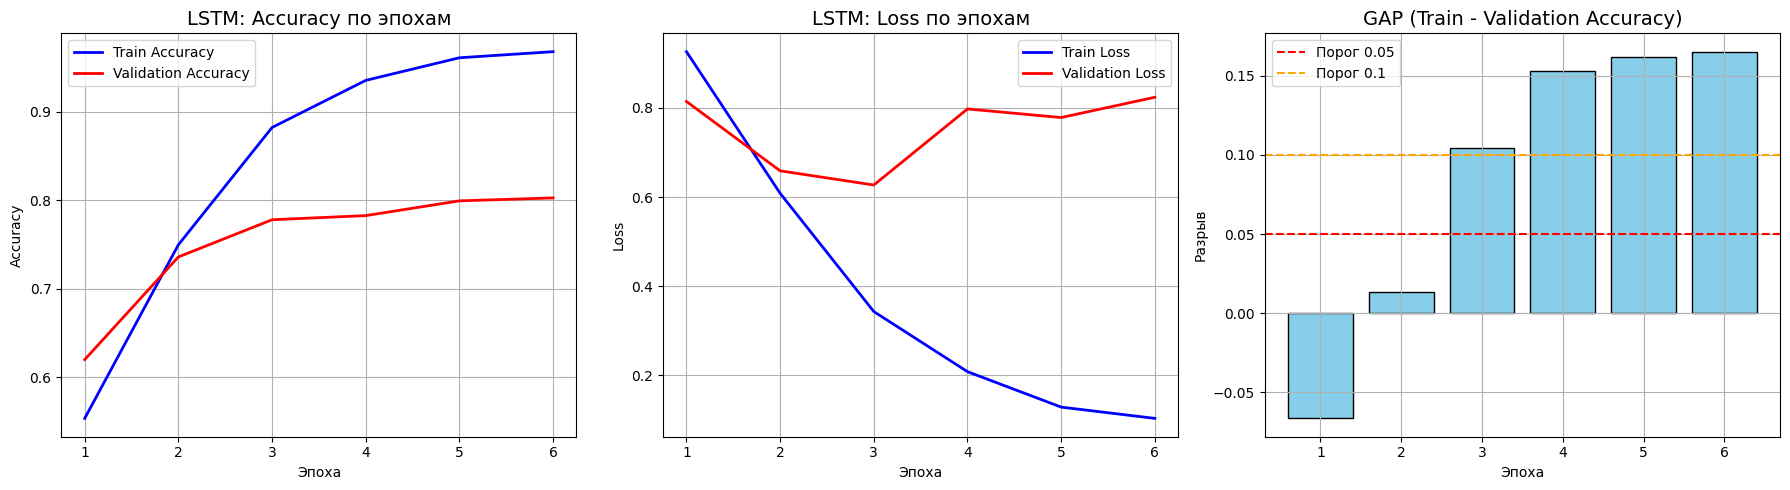

In [92]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

gap = [train_acc[i] - val_acc[i] for i in range(len(train_acc))]

print(f"Лучшая val_accuracy: {max(val_acc):.4f} (эпоха {val_acc.index(max(val_acc))+1})")
print(f"Финальная train_accuracy: {train_acc[-1]:.4f}")
print(f"Финальная val_accuracy: {val_acc[-1]:.4f}")
print(f"GAP (train - val) на последней эпохе: {gap[-1]:.4f}")

# Оценка переобучения
if gap[-1] > 0.1:
    print("Значительный разрыв (>0.1) — есть переобучение.")
elif gap[-1] > 0.05:
    print("Умеренный разрыв (>0.05) — возможное переобучение.")
else:
    print("Разрыв небольшой (<0.05) — модель обобщает хорошо.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
axes[0].plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
axes[0].set_title('LSTM: Accuracy по эпохам', fontsize=14)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
axes[1].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
axes[1].set_title('LSTM: Loss по эпохам', fontsize=14)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].bar(epochs, gap, color='skyblue', edgecolor='black')
axes[2].axhline(y=0.05, color='red', linestyle='--', label='Порог 0.05')
axes[2].axhline(y=0.1, color='orange', linestyle='--', label='Порог 0.1')
axes[2].set_title('GAP (Train - Validation Accuracy)', fontsize=14)
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('Разрыв')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('lstm_training_analysis.png', dpi=300)
plt.show()

In [95]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch
import numpy as np

sample_size_bert = 15000
indices_bert = np.random.choice(len(X_train_text), sample_size_bert)
X_train_bert = X_train_text[indices_bert]
y_train_bert = y_train_text[indices_bert]

print(f"Обучающая выборка ruBERT: {len(X_train_bert)} отзывов")

Обучающая выборка ruBERT: 15000 отзывов


In [96]:
model_name = "blanchefort/rubert-base-cased-sentiment"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, attn_implementation="eager")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [97]:
train_encodings = tokenizer_bert(
    list(X_train_bert),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

test_encodings = tokenizer_bert(
    list(X_test),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

In [98]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

    def __len__(self):
        return len(self.labels)

In [99]:
train_dataset = SentimentDataset(train_encodings, y_train_bert)
test_dataset = SentimentDataset(test_encodings, y_test_text)

In [100]:
training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=2e-5,
    dataloader_num_workers=0,
    dataloader_pin_memory=False
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


In [101]:
trainer.train()

predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

acc_bert = accuracy_score(y_test_text, y_pred_bert)
f1_bert = f1_score(y_test_text, y_pred_bert, average='macro')

print(f"Результаты ruBERT:")
print(f"  Accuracy: {acc_bert:.4f}")
print(f"  F1-macro: {f1_bert:.4f}")

Epoch,Training Loss,Validation Loss
1,0.976871,1.601690
2,0.667722,2.077350
3,0.713104,2.283189


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Результаты ruBERT:
  Accuracy: 0.6301
  F1-macro: 0.5761


# **Сравнение моделей**

             Модель  Accuracy  F1-macro
Logistic Regression  0.651059  0.590614
        Naive Bayes  0.585507  0.460918
               LSTM  0.598439  0.549763
             ruBERT  0.630100  0.576122
Лучшая модель: Logistic Regression (Accuracy: 0.6511)


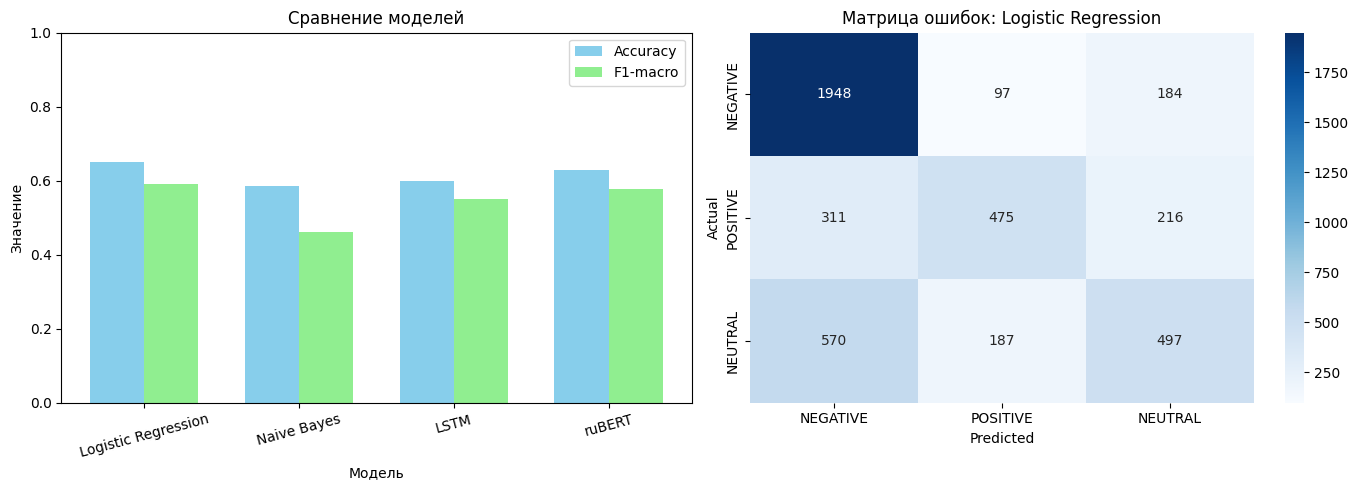

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

results_df = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Naive Bayes', 'LSTM', 'ruBERT'],
    'Accuracy': [acc_lr, acc_nb, acc_lstm, acc_bert],
    'F1-macro': [f1_lr, f1_nb, f1_lstm, f1_bert]
})

print(results_df.to_string(index=False))

best_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Модель']
print(f"Лучшая модель: {best_model_name} (Accuracy: {results_df.loc[best_idx, 'Accuracy']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(results_df))
width = 0.35
axes[0].bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
axes[0].bar(x + width/2, results_df['F1-macro'], width, label='F1-macro', color='lightgreen')
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('Значение')
axes[0].set_title('Сравнение моделей')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Модель'], rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1)

if best_model_name == 'Logistic Regression':
    best_pred = y_pred_lr
elif best_model_name == 'Naive Bayes':
    best_pred = y_pred_nb
elif best_model_name == 'LSTM':
    best_pred = y_pred_lstm
else:
    best_pred = y_pred_bert

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['NEGATIVE', 'POSITIVE', 'NEUTRAL'],
            yticklabels=['NEGATIVE', 'POSITIVE', 'NEUTRAL'])
axes[1].set_title(f'Матрица ошибок: {best_model_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# **Влияние сленга на работу моделей**

In [104]:
slang_words = [
    'топ', 'имба', 'огонь', 'бомба', 'круто', 'зачёт',
    'отстой', 'говно', 'шлак', 'хлам', 'мусор', 'фигня', 'херня',
    'бред', 'треш', 'жесть', 'кайф', 'норм', 'четко',
    'опупеть', 'зашибись', 'очуметь', 'трындец', 'пипец', 'мочить', 'хавать',
    'чувак', 'старпер', 'мутный', 'бухать',
    'гонишь', 'тупишь', 'туса', 'шняга', 'стремно', 'хавка',
    'супер', 'прикольно', 'пофиг'
]

def count_slang(text):
    text_lower = str(text).lower()
    return sum(1 for word in slang_words if word in text_lower)

df_test = pd.DataFrame({
    'text': X_test,
    'true_label': y_test,
    'pred_bert': y_pred_bert,
    'pred_lr': y_pred_lr
})

df_test['slang_count'] = df_test['text'].apply(count_slang)
df_test['has_slang'] = df_test['slang_count'] > 0
df_test['correct_bert'] = df_test['true_label'] == df_test['pred_bert']
df_test['correct_lr'] = df_test['true_label'] == df_test['pred_lr']

slang_analysis = df_test.groupby('has_slang').agg({
    'correct_bert': 'mean',
    'correct_lr': 'mean',
    'text': 'count'
}).rename(columns={
    'correct_bert': 'Accuracy_ruBERT',
    'correct_lr': 'Accuracy_LR',
    'text': 'Count'
})

print("Сравнение точности:")
print(slang_analysis.to_string())

print("Примеры отзывов со сленгом:")
slang_samples = df_test[df_test['has_slang'] == True].head(5)
for idx, row in slang_samples.iterrows():
    print(f"Текст: {row['text'][:150]}...")
    print(f"Тональность: {row['true_label']}")
    print(f"Сленговых слов: {row['slang_count']}")


if True in slang_analysis.index and False in slang_analysis.index:
    acc_with_slang = slang_analysis.loc[True, 'Accuracy_ruBERT']
    acc_without_slang = slang_analysis.loc[False, 'Accuracy_ruBERT']
    diff = acc_with_slang - acc_without_slang
    print(f"Точность ruBERT на отзывах со сленгом: {acc_with_slang:.4f}")
    print(f"Точность ruBERT на отзывах без сленга: {acc_without_slang:.4f}")

Сравнение точности:
           Accuracy_ruBERT  Accuracy_LR  Count
has_slang                                     
False             0.628508     0.654626   3599
True              0.636569     0.636569    886
Примеры отзывов со сленгом:
Текст: ронять мочить музыка слушать бережно эксплуатировать четыре месяц захрипеть полифонический динамик грустнот...
Тональность: 1
Сленговых слов: 1
Текст: версия длиный обычный мм диапозон это специальный серия сингапур общий китайский рынок москва подмосковье связь отличный покупать глобальный прошивка ...
Тональность: 0
Сленговых слов: 2
Текст: телефон нормальный корпус...
Тональность: 2
Сленговых слов: 1
Текст: подруга купить одинаковый январь черный белыйесли использовать чехол белый очень заметно затерсяз это время телефон неоднократно падалиу подруга разле...
Тональность: 0
Сленговых слов: 1
Текст: вообщий вчера купить сей замечательный аппарат магазин повертеть покрутить вроде понравиться это обычно происходить недостаток обнаруживаться чуточку

# **График LSTM**

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


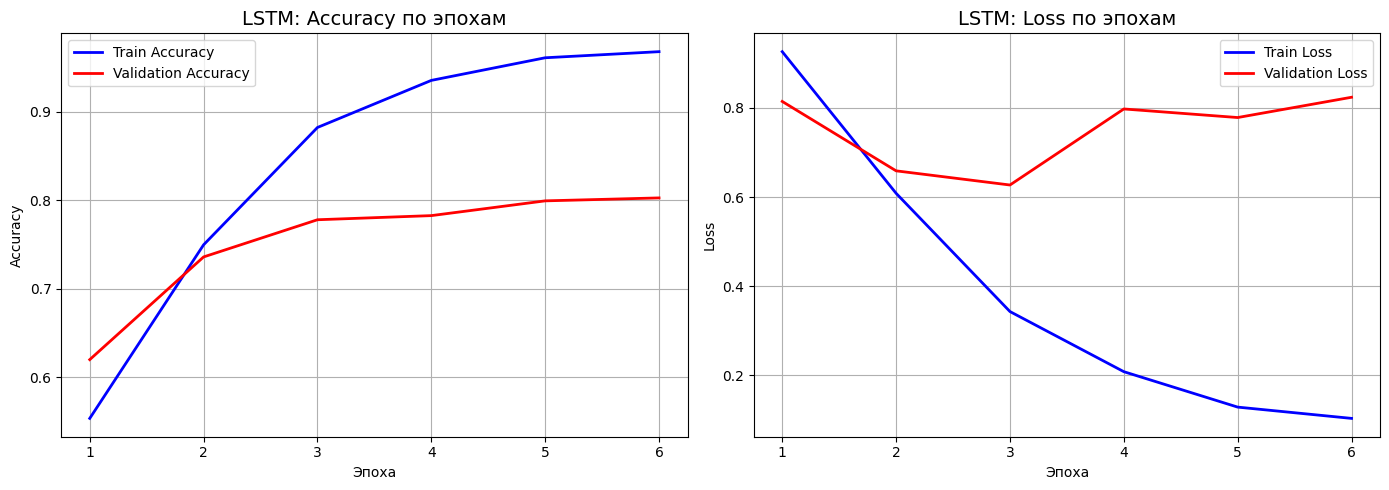

In [105]:
import matplotlib.pyplot as plt

print(history.history.keys())

# Извлекаем данные
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

# Строим графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График точности
axes[0].plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
axes[0].plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
axes[0].set_title('LSTM: Accuracy по эпохам', fontsize=14)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# График потерь
axes[1].plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
axes[1].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
axes[1].set_title('LSTM: Loss по эпохам', fontsize=14)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **График ruBERT**

Всего записей в логах: 229
Первые 5 записей:
{'loss': 2.3322409057617186, 'grad_norm': 83.03723907470703, 'learning_rate': 3.96e-06, 'epoch': 0.013333333333333334, 'step': 100}
{'loss': 1.417060089111328, 'grad_norm': 5.42970085144043, 'learning_rate': 7.960000000000002e-06, 'epoch': 0.02666666666666667, 'step': 200}
{'loss': 1.0283393096923827, 'grad_norm': 4.495878219604492, 'learning_rate': 1.196e-05, 'epoch': 0.04, 'step': 300}
{'loss': 0.8486909484863281, 'grad_norm': 16.42456817626953, 'learning_rate': 1.5960000000000003e-05, 'epoch': 0.05333333333333334, 'step': 400}
{'loss': 0.8129700469970703, 'grad_norm': 181.20797729492188, 'learning_rate': 1.9960000000000002e-05, 'epoch': 0.06666666666666667, 'step': 500}


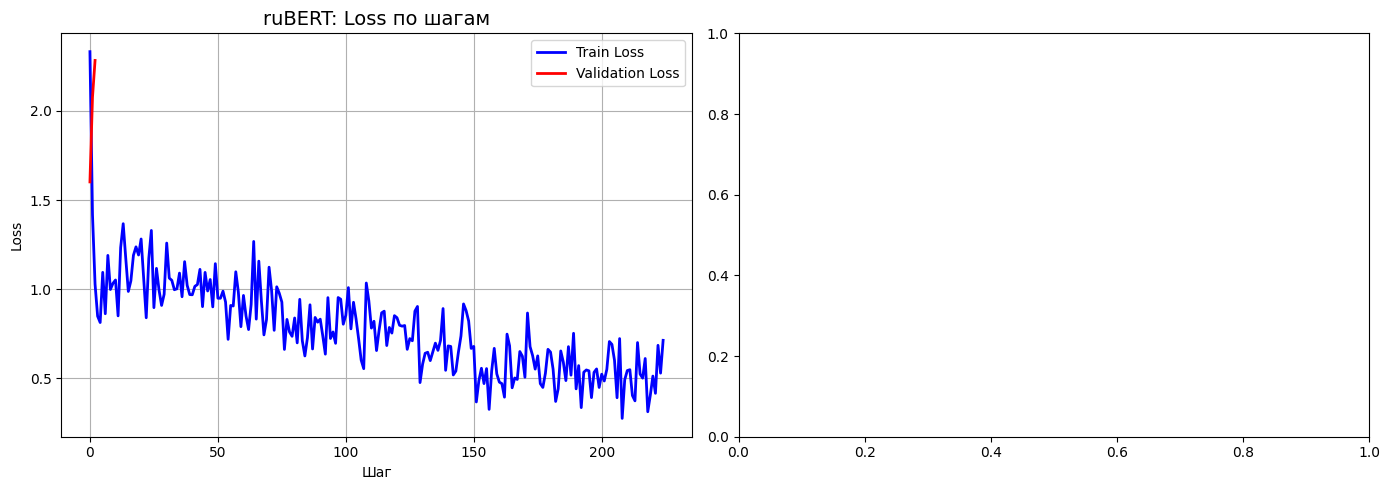

In [106]:
print(f"Всего записей в логах: {len(trainer.state.log_history)}")

# Показываем первые 5 записей, чтобы понять структуру
print("Первые 5 записей:")
for log in trainer.state.log_history[:5]:
    print(log)

# Извлекаем данные
train_loss = []
val_loss = []
val_accuracy = []
steps = []

for i, log in enumerate(trainer.state.log_history):
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps.append(i)
    if 'eval_loss' in log:
        val_loss.append(log['eval_loss'])
    if 'eval_accuracy' in log:
        val_accuracy.append(log['eval_accuracy'])

# Строим графики
if train_loss or val_loss:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    if train_loss:
        axes[0].plot(range(len(train_loss)), train_loss, 'b-', label='Train Loss', linewidth=2)
    if val_loss:
        axes[0].plot(range(len(val_loss)), val_loss, 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_title('ruBERT: Loss по шагам', fontsize=14)
    axes[0].set_xlabel('Шаг')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Validation Accuracy
    if val_accuracy:
        axes[1].plot(range(len(val_accuracy)), val_accuracy, 'g-', label='Validation Accuracy', linewidth=2)
        axes[1].set_title('ruBERT: Validation Accuracy', fontsize=14)
        axes[1].set_xlabel('Шаг')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Нет данных для построения графиков.")

In [107]:
!pip install fastapi uvicorn nest-asyncio pyngrok

# **Общий вывод**

In [108]:
print(f"""
1. Сбор данных: {len(df)} отзывов о телефонах
2. Разметка тональности: выполнена через ruBERT
3. Предобработка: нормализация, удаление шума, токенизация
4. Обучены модели: Logistic Regression, Naive Bayes, LSTM, ruBERT

РЕЗУЛЬТАТЫ:
   Logistic Regression: Accuracy = {acc_lr:.4f}, F1-macro = {f1_lr:.4f}
   Naive Bayes:        Accuracy = {acc_nb:.4f}, F1-macro = {f1_nb:.4f}
   LSTM:               Accuracy = {acc_lstm:.4f}, F1-macro = {f1_lstm:.4f}
   ruBERT:             Accuracy = {acc_bert:.4f}, F1-macro = {f1_bert:.4f}

Лучшая модель: {best_model_name} (Accuracy: {results_df.loc[best_idx, 'Accuracy']:.4f})
""")


1. Сбор данных: 22421 отзывов о телефонах
2. Разметка тональности: выполнена через ruBERT
3. Предобработка: нормализация, удаление шума, токенизация
4. Обучены модели: Logistic Regression, Naive Bayes, LSTM, ruBERT

РЕЗУЛЬТАТЫ:
   Logistic Regression: Accuracy = 0.6511, F1-macro = 0.5906
   Naive Bayes:        Accuracy = 0.5855, F1-macro = 0.4609
   LSTM:               Accuracy = 0.5984, F1-macro = 0.5498
   ruBERT:             Accuracy = 0.6301, F1-macro = 0.5761

Лучшая модель: Logistic Regression (Accuracy: 0.6511)



# **Ансамбли**

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split

X_meta = np.column_stack([
    y_pred_lr,
    y_pred_nb,
    y_pred_lstm,
    y_pred_bert
])

meta_model = LogisticRegression(max_iter=1000, random_state=42)

X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_meta, y_test, test_size=0.3, random_state=42
)

meta_model.fit(X_meta_train, y_meta_train)
y_pred_meta = meta_model.predict(X_meta_test)

acc_meta = accuracy_score(y_meta_test, y_pred_meta)
f1_meta = f1_score(y_meta_test, y_pred_meta, average='macro')

print(f"Результаты стеккинга:")
print(f"  Accuracy: {acc_meta:.4f}")
print(f"  F1-macro: {f1_meta:.4f}")

Результаты стеккинга:
  Accuracy: 0.5884
  F1-macro: 0.4737


In [114]:
from scipy.special import softmax
import numpy as np
from sklearn.metrics import accuracy_score, f1_score


if 'lr' in locals() and hasattr(lr, 'predict_proba'):
    y_pred_lr_proba = lr.predict_proba(X_test_tfidf)
    print("Вероятности LR получены")
else:
    print("LR не обучен или нет predict_proba")

if 'predictions' in locals():
    logits = predictions.predictions
    y_pred_bert_proba = softmax(logits, axis=1)
    print("Вероятности ruBERT получены")
else:
    print("Нет предсказаний ruBERT.")

weight_bert = 0.7
weight_lr = 0.3

# Комбинируем вероятности
ensemble_proba = weight_bert * y_pred_bert_proba + weight_lr * y_pred_lr_proba
y_pred_ensemble = np.argmax(ensemble_proba, axis=1)

acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='macro')

print(f"  Веса: ruBERT {weight_bert*100:.0f}% + LR {weight_lr*100:.0f}%")
print(f"  Accuracy: {acc_ensemble:.4f}")
print(f"  F1-macro: {f1_ensemble:.4f}")

print("Сравнение с отдельными моделями:")
print(f"  ruBERT:          Accuracy = {acc_bert:.4f}")
print(f"  Logistic Regression: Accuracy = {acc_lr:.4f}")
print(f"  Ансамбль:        Accuracy = {acc_ensemble:.4f}")
print(f"  Улучшение:       +{(acc_ensemble - acc_bert)*100:.2f}%")

Вероятности LR получены
Вероятности ruBERT получены
  Веса: ruBERT 70% + LR 30%
  Accuracy: 0.6308
  F1-macro: 0.5759
Сравнение с отдельными моделями:
  ruBERT:          Accuracy = 0.6301
  Logistic Regression: Accuracy = 0.6511
  Ансамбль:        Accuracy = 0.6308
  Улучшение:       +0.07%


# **CatBoostClassifier**

In [116]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train_tfidf, y_train)

# Предсказание и оценка
y_pred_cat = cat_model.predict(X_test_tfidf)
acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average='macro')

print(f"CatBoost Accuracy: {acc_cat:.4f}")
print(f"CatBoost F1-macro: {f1_cat:.4f}")

0:	learn: 1.0732801	total: 3.73s	remaining: 31m 2s
100:	learn: 0.8576536	total: 4m 50s	remaining: 19m 7s
200:	learn: 0.8024976	total: 8m 25s	remaining: 12m 32s
300:	learn: 0.7708581	total: 10m 56s	remaining: 7m 13s
400:	learn: 0.7481688	total: 13m 47s	remaining: 3m 24s
499:	learn: 0.7310346	total: 16m 28s	remaining: 0us
CatBoost Accuracy: 0.6448
CatBoost F1-macro: 0.5894


# **Матрицы ошибок для всех моделей, которые попробовали**

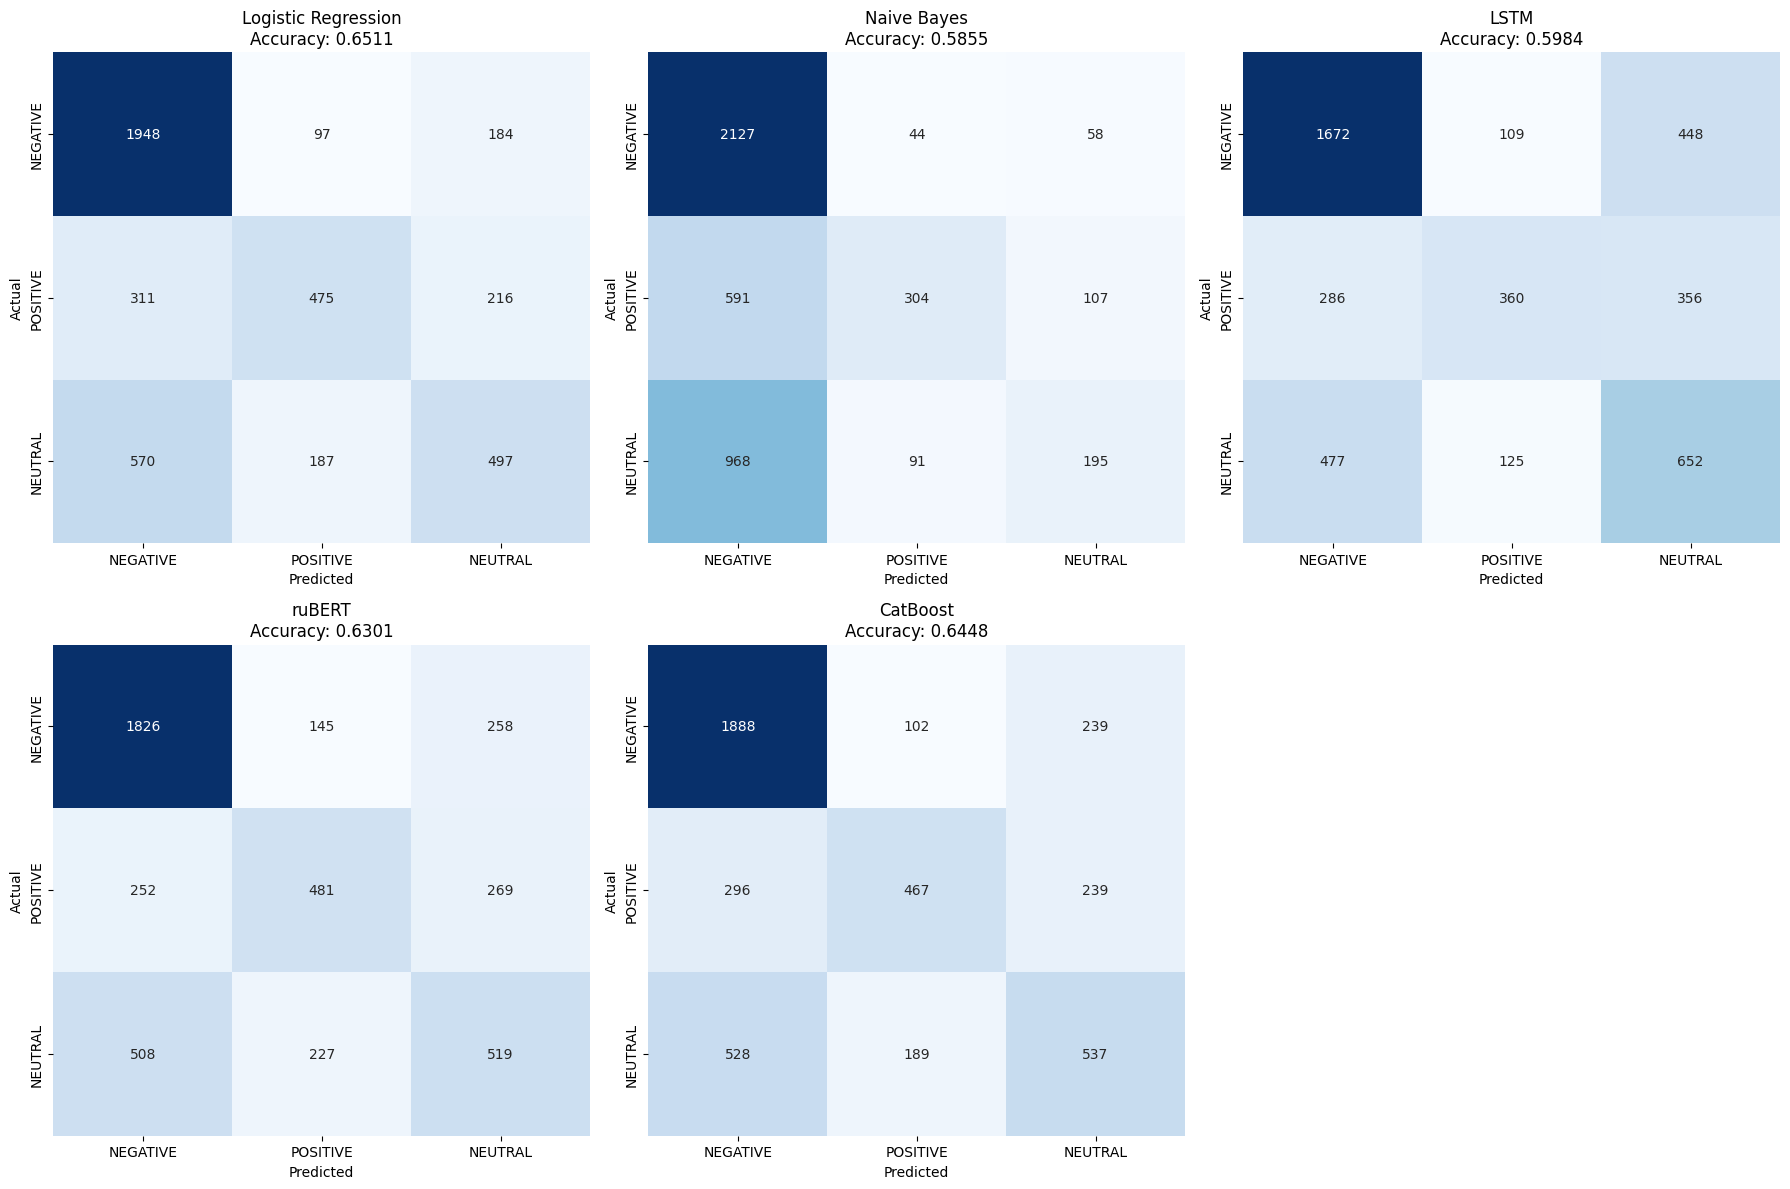

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

models = {
    'Logistic Regression': y_pred_lr,
    'Naive Bayes': y_pred_nb,
    'LSTM': y_pred_lstm,
    'ruBERT': y_pred_bert,
    'CatBoost': y_pred_cat
}

class_names = ['NEGATIVE', 'POSITIVE', 'NEUTRAL']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test_text, pred)

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                cbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test_text, pred):.4f}', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

for idx in range(len(models), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=300)
plt.show()

# **Реализация API**

In [112]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import uvicorn
import threading
import time
import requests
import torch
from transformers import pipeline

app = FastAPI(title="Sentiment Analysis API")

class ReviewRequest(BaseModel):
    text: str

class SentimentResponse(BaseModel):
    sentiment: str
    confidence: float

try:
    sentiment_pipeline
except NameError:
    device = 0 if torch.cuda.is_available() else -1
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="blanchefort/rubert-base-cased-sentiment",
        tokenizer="blanchefort/rubert-base-cased-sentiment",
        device=device
    )

@app.post("/predict", response_model=SentimentResponse)
def predict(request: ReviewRequest):
    if not request.text.strip():
        raise HTTPException(status_code=400, detail="Текст не может быть пустым")
    result = sentiment_pipeline(request.text[:512])[0]
    return SentimentResponse(
        sentiment=result['label'],
        confidence=result['score']
    )

@app.get("/")
def root():
    return {"message": "Sentiment Analysis API is running!"}

def run_api():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")

thread = threading.Thread(target=run_api, daemon=True)
thread.start()

time.sleep(3)
print("✅ Сервер запущен на http://127.0.0.1:8000")

test_text = "Отличный телефон, очень доволен покупкой!"
try:
    response = requests.post(
        "http://127.0.0.1:8000/predict",
        json={"text": test_text},
        timeout=5
    )
    if response.status_code == 200:
        print("Ответ API:")
        print(response.json())
    else:
        print(f"Ошибка: {response.status_code}")
        print(response.text)
except requests.exceptions.ConnectionError:
    print("Не удалось подключиться к серверу. Проверьте, что он запущен.")

✅ Сервер запущен на http://127.0.0.1:8000
Ответ API:
{'sentiment': 'POSITIVE', 'confidence': 0.9811021685600281}
